fr

In [1]:
import ase.spectrum.band_structure
from ase.io import read
from ase.visualize import view
from gpaw import GPAW, PW, FermiDirac

In [ ]:
atoms = read('gnr_relax.xyz')
view(atoms)

In [7]:
calc = GPAW(
    mode=PW(500),          # 500 eV cutoff is a good start
    xc='PBE',
    spinpol=True,          # you used spin before, keep it
    occupations=FermiDirac(0.1),
    kpts=(1, 1, 20),       # k-point sampling along ribbon axis
    txt='gnr_scf_pw.txt'
)

atoms.calc = calc

# Run the SCF
E = atoms.get_potential_energy()
print("SCF energy:", E, "eV")

# Save restart file
calc.write('gnr_pw.gpw', mode='all')

SCF energy: -307.36330323686406 eV


In [2]:
from gpaw import restart

atoms_loaded, calc_loaded = restart('gnr_pw.gpw')

In [3]:
from ase.spectrum.dosdata import RawDOSData
d: RawDOSData = calc_loaded.get_dos()

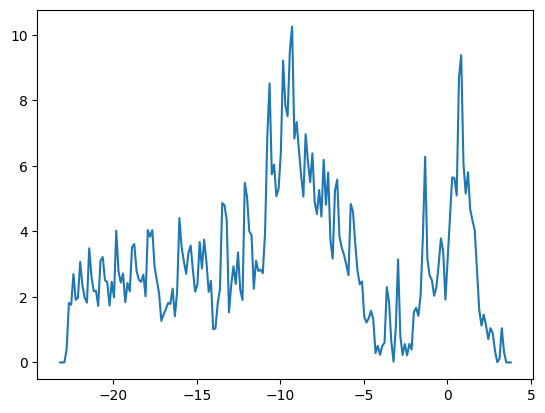

In [4]:
import matplotlib.pyplot as plt

plt.plot(d[0], d[1])

In [ ]:
# --- choose a reasonable number of bands ---
nel = calc_loaded.get_number_of_electrons()
nbands = int(nel/2) + 20   # occupied + 20 empty (adjust later)

# --- fixed-density band calculation ---
calc_fixed = calc_loaded.fixed_density(
    nbands=nbands,
    symmetry='off',
    kpts={'path': 'GX', 'npoints': 30},   # start with 30 points
    convergence={'bands': 4},
    txt='bands_fixed_density.txt'
)

In [ ]:
bs = calc_fixed.band_structure()
bs.plot(show=True)

In [11]:
from ase.dft.kpoints import bandpath

In [12]:
nbands = 3 * atoms_loaded.get_number_of_atoms()

/tmp/ipykernel_460/2023691788.py:1: FutureWarning: Please use len(self) or, if your atoms are distributed, self.get_global_number_of_atoms.
  nbands = 3 * atoms_loaded.get_number_of_atoms()
